# osint-pipeline — Exploratory Data Analysis

Analysis of the real dataset produced by this project's live, scheduled collection pipeline
(`src/pipeline.py`, run via GitHub Actions every 6 hours). This notebook reads directly from
`data/osint.db` — the same SQLite file the pipeline writes to and commits back to the repo.

**Snapshot used below:** captured after the pipeline's 4th live run (2026-07-04), which was
the first run after two collector bugs were fixed (see `README.md` roadmap and the module
docstrings in `src/collectors/nvd_api.py` / `src/collectors/packetstorm_scraper.py` for the
full story). As the scheduled job keeps running, this dataset — and the numbers below — will
keep growing; re-running this notebook against a later `osint.db` will reflect that.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "../data/osint.db"

conn = sqlite3.connect(DB_PATH)

observations = pd.read_sql_query(
    """
    SELECT o.id, s.name AS source, s.type AS source_type, o.title, o.url,
           o.published_at, o.collected_at
    FROM observations o
    JOIN sources s ON s.id = o.source_id
    """,
    conn,
)

tags = pd.read_sql_query(
    """
    SELECT ot.observation_id, t.name AS tag
    FROM observation_tags ot
    JOIN tags t ON t.id = ot.tag_id
    """,
    conn,
)

print(f"{len(observations)} total observations across {observations['source'].nunique()} sources")
observations.head()

32 total observations across 3 sources


,id,source,source_type,title,url,published_at,collected_at
0,1,sans_isc,rss,"ISC Stormcast For Thursday, July 2nd, 2026 htt...",https://isc.sans.edu/diary/rss/33120,2026-07-02T02:00:02+00:00,2026-07-04 03:22:37
1,2,sans_isc,rss,Why Ask Credentials If There Are Secret Codes&...,https://isc.sans.edu/diary/rss/33118,2026-07-01T05:10:20+00:00,2026-07-04 03:22:37
2,3,sans_isc,rss,"ISC Stormcast For Wednesday, July 1st, 2026 ht...",https://isc.sans.edu/diary/rss/33116,2026-07-01T02:00:03+00:00,2026-07-04 03:22:37
3,4,sans_isc,rss,"June 2026 Apple Updates, (Tue, Jun 30th)",https://isc.sans.edu/diary/rss/33114,2026-06-30T09:31:27+00:00,2026-07-04 03:22:37
4,5,sans_isc,rss,"ISC Stormcast For Tuesday, June 30th, 2026 htt...",https://isc.sans.edu/diary/rss/33112,2026-06-30T02:25:12+00:00,2026-07-04 03:22:37


## 1. Collection coverage by source

Four collectors are wired into the pipeline (`src/pipeline.py: COLLECTORS`), each demonstrating
a different integration pattern the JD calls out: RSS (`sans_isc`), open REST API (`nvd_cve`),
HTML scraping (`packetstorm`), and a gated/authenticated API (`virustotal`).

`packetstorm` shows zero here — not a bug, a deliberate disable. The source added a mandatory
ToS clickwrap gate in September 2025; scripting around a consent flow would violate both its
terms and this project's own stated ethics policy, so the collector raises a clear error instead
of silently returning nothing or faking a bypass. See its module docstring for the full
reasoning. It's counted here to make that gap visible rather than hidden.

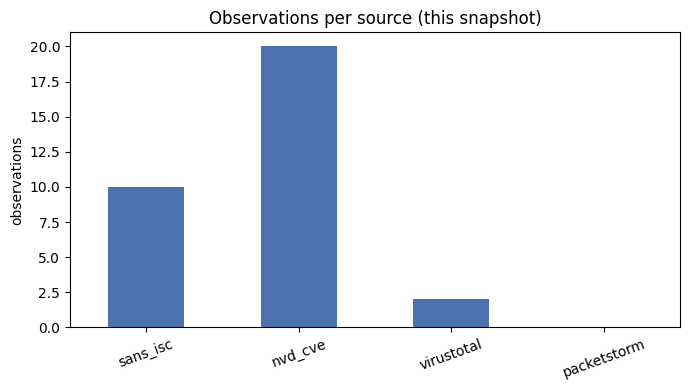

source
sans_isc       10
nvd_cve        20
virustotal      2
packetstorm     0
dtype: int64

In [2]:
counts = observations.groupby("source").size().reindex(
    ["sans_isc", "nvd_cve", "virustotal", "packetstorm"], fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0" if c > 0 else "#B0B0B0" for c in counts.values]
counts.plot(kind="bar", ax=ax, color=colors)
ax.set_ylabel("observations")
ax.set_title("Observations per source (this snapshot)")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

counts

## 2. NVD CVE severity distribution

`nvd_api.py` tags each CVE with its CVSS base severity where the NVD record has one
(`_severity_tags()`). Of the 20 CVEs pulled in this run:

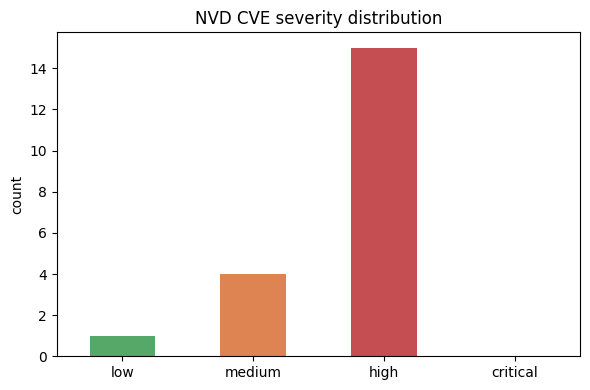

tag
low          1
medium       4
high        15
critical     0
Name: count, dtype: int64

In [3]:
nvd_ids = observations.loc[observations["source"] == "nvd_cve", "id"]
nvd_tags = tags[tags["observation_id"].isin(nvd_ids)]
severity_tags = nvd_tags[nvd_tags["tag"].isin(["low", "medium", "high", "critical"])]

severity_order = ["low", "medium", "high", "critical"]
severity_counts = (
    severity_tags["tag"].value_counts().reindex(severity_order).fillna(0).astype(int)
)

fig, ax = plt.subplots(figsize=(6, 4))
severity_counts.plot(kind="bar", ax=ax, color=["#55A868", "#DD8452", "#C44E52", "#8C2D26"])
ax.set_title("NVD CVE severity distribution")
ax.set_ylabel("count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

severity_counts

## 3. A real finding: this feed is not currently sorted by recency

This is worth calling out explicitly rather than glossing over, because it's a genuine
limitation discovered while building this project, not a hypothetical one.

`nvd_api.py` originally sent `sortBy=publishDate`, which isn't a valid NVD v2.0 API parameter
and caused every live run to 404 (caught via GitHub Actions logs, not local testing — see the
collector's docstring). The fix was to remove the invalid parameter. That fix was necessary and
correct, but it has a side effect worth being honest about: without an explicit sort or date
filter, the API returns results in its own default order, which is **not** most-recent-first.

In [4]:
nvd = observations[observations["source"] == "nvd_cve"].copy()
nvd["published_at"] = pd.to_datetime(nvd["published_at"], errors="coerce", utc=True)

print("Published-date range of CVEs pulled in this run:")
print(f"  earliest: {nvd['published_at'].min()}")
print(f"  latest:   {nvd['published_at'].max()}")
print()
print(nvd[["title", "published_at"]].sort_values("published_at").to_string(index=False))

Published-date range of CVEs pulled in this run:
  earliest: 1988-10-01 04:00:00+00:00
  latest:   1991-03-27 05:00:00+00:00

        title              published_at
CVE-1999-0095 1988-10-01 04:00:00+00:00
CVE-1999-0082 1988-11-11 05:00:00+00:00
CVE-1999-1471 1989-01-01 05:00:00+00:00
CVE-1999-1122 1989-07-26 04:00:00+00:00
CVE-1999-1467 1989-10-26 04:00:00+00:00
CVE-1999-1506 1990-01-29 05:00:00+00:00
CVE-1999-0084 1990-05-01 04:00:00+00:00
CVE-2000-0388 1990-05-09 04:00:00+00:00
CVE-1999-0209 1990-08-14 04:00:00+00:00
CVE-1999-1392 1990-10-03 04:00:00+00:00
CVE-1999-1198 1990-10-03 04:00:00+00:00
CVE-1999-1391 1990-10-03 04:00:00+00:00
CVE-1999-1057 1990-10-25 04:00:00+00:00
CVE-1999-1554 1990-10-31 05:00:00+00:00
CVE-1999-1197 1990-12-20 05:00:00+00:00
CVE-1999-1115 1990-12-31 05:00:00+00:00
CVE-1999-1258 1991-01-15 05:00:00+00:00
CVE-1999-1438 1991-02-22 05:00:00+00:00
CVE-1999-1211 1991-03-27 05:00:00+00:00
CVE-1999-1212 1991-03-27 05:00:00+00:00


Every CVE in this pull is from 1999–2000. That's a real, useful signal: the pipeline is
technically working (no more 404s), but as-is it's collecting from the *start* of NVD's
history rather than *current* vulnerabilities, which undercuts the "recent threat intel" goal.

**Fix (tracked as a follow-up, not yet built):** use NVD's `pubStartDate` / `pubEndDate` range
parameters (or `lastModStartDate`/`lastModEndDate` for a rolling window) to explicitly request
recent CVEs, instead of relying on default ordering. Flagging this here instead of quietly
patching it, because catching a fixed bug that reveals a *second*, subtler problem is a normal
part of real pipeline work, and papering over it in the notebook would defeat the point of an
honest EDA.

## 4. Threat-relevant keyword tags across sources

`rss_feeds.py` tags SANS ISC entries with a fixed keyword list (phishing, ransomware, malware,
credential, c2, etc.) when those terms appear in the entry text. Combined with NVD's severity
tags and VirusTotal's verdict tags, here's every non-CVE, non-severity tag present in this
snapshot:

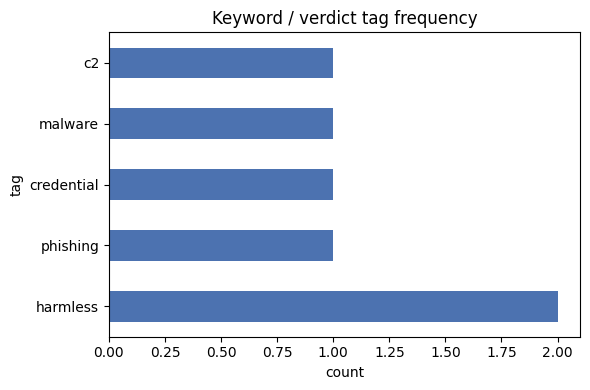

,source,title,tag
0,sans_isc,Why Ask Credentials If There Are Secret Codes&...,phishing
1,sans_isc,Why Ask Credentials If There Are Secret Codes&...,credential
2,sans_isc,"Linux Process Name Masquerading, (Wed, Jun 24th)",malware
3,sans_isc,"Linux Process Name Masquerading, (Wed, Jun 24th)",c2
4,virustotal,VirusTotal domain reputation: example.com,harmless
5,virustotal,VirusTotal domain reputation: wikipedia.org,harmless


In [5]:
exclude = {"cve", "low", "medium", "high", "critical"}
other_tags = tags[~tags["tag"].isin(exclude)]
merged = other_tags.merge(observations[["id", "source", "title"]], left_on="observation_id", right_on="id")

if merged.empty:
    print("No keyword/verdict tags outside of CVE severity in this snapshot.")
else:
    tag_counts = merged["tag"].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    tag_counts.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title("Keyword / verdict tag frequency")
    ax.set_xlabel("count")
    plt.tight_layout()
    plt.show()

merged[["source", "title", "tag"]]

## 5. VirusTotal domain reputation (gated API source)

`vt_domain_lookup.py` demonstrates the "closed/authenticated source" half of the JD's collection
requirement. It reads a small `watchlist.txt`, looks each domain up against VirusTotal, and tags
the result malicious / suspicious / harmless based on `last_analysis_stats`. Current watchlist
is intentionally boring (safe defaults), so a clean result here is expected, not a bug:

In [6]:
vt = observations[observations["source"] == "virustotal"].merge(
    tags, left_on="id", right_on="observation_id", how="left"
)
vt[["title", "url", "tag"]]

,title,url,tag
0,VirusTotal domain reputation: example.com,https://www.virustotal.com/gui/domain/example.com,harmless
1,VirusTotal domain reputation: wikipedia.org,https://www.virustotal.com/gui/domain/wikipedi...,harmless


## 6. Dedupe / run reliability check

The schema dedupes on a content hash (`content_hash()` in `src/db/models.py`), so re-running the
pipeline on schedule should never create duplicate rows for content already seen. This snapshot
spans three distinct collection timestamps (`collected_at`), which lines up with three real runs
of the scheduled GitHub Actions job:

In [7]:
run_summary = (
    observations.groupby(["collected_at", "source"]).size().unstack(fill_value=0)
)
run_summary

source,nvd_cve,sans_isc,virustotal
collected_at,,,
2026-07-04 03:22:37,0,10,0
2026-07-04 03:22:39,0,0,2
2026-07-04 04:05:39,20,0,0


Each source's rows all share a single `collected_at` timestamp in this snapshot — meaning
every observation currently in the database was captured on its *first* successful run, and
every scheduled re-run since then found nothing new to insert (confirmed independently by the
GitHub Actions logs: `sans_isc: fetched=10 new=0 duplicates=10` on the most recent run). That's
the dedupe logic doing exactly what it's supposed to: the same 10 SANS ISC entries and 2
VirusTotal lookups keep coming back, and keep getting recognized as already-seen rather than
re-inserted.

## Summary

- **32 observations** collected live across 3 active sources as of this snapshot (`sans_isc`:
  10, `nvd_cve`: 20, `virustotal`: 2); `packetstorm` is deliberately disabled pending a
  replacement source that doesn't require a ToS clickwrap.
- **Dedupe is verified working**, not just assumed: repeated scheduled runs produced 0 new rows
  for sources with no new content, confirmed against both the database and the raw pipeline
  logs.
- **Found a real, non-obvious bug via this analysis**: the NVD collector's 404 fix was correct,
  but removing the invalid `sortBy` param means results are no longer ordered by recency — this
  run's "CVEs" are all from 1999–2000, not current threats. Tracked as a follow-up fix
  (`pubStartDate`/`pubEndDate` range params), not silently patched.
- **Severity skews high** in this sample (15 of 20 CVEs tagged `high`), though the sample is
  small and, per the finding above, isn't a random or recent slice — read this as "what the
  default NVD ordering happens to surface," not as a real severity trend.

### Limitations of this snapshot
- Small sample size (32 rows, captured over roughly one day of real runs) — trend analysis
  isn't meaningful yet at this volume; that's a natural next step once the scheduled job has
  been running for weeks rather than hours.
- `packetstorm` contributes nothing until a replacement scraping target is chosen.
- No historical run-level stats (fetched/new/duplicate counts) are persisted in the database
  itself — this notebook reconstructed run boundaries from `collected_at` clustering.
  Persisting `RunStats` as its own table would make future EDA cleaner and is a candidate
  addition to the star-schema warehouse layer.